In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings("ignore")

In [2]:
def wrangle (filepath):
    df = pd.read_csv(filepath)
    
    # Dropping duplicates
    df = df.drop_duplicates()
    
    # Removing price outliers (top 1%)
    df = df[(df["price"]>=df["price"].quantile(0.01))& (df["price"]<=df["price"].quantile(0.99))]

    # Dropping high-cardinality and low-correlation columns
    df = df.drop(columns=[ "parking_space"])  # 189 unique towns, parking_space corr=0.05
    
    # Dropping multicollinear columns
    df = df.drop(columns=["toilets"]) # highly correlated with bathrooms (0.79)

    # Filter to Lagos and Abuja only
    df = df[df["state"].isin(["Lagos", "Abuja"])]
    
    return df

In [3]:
df=wrangle("../data/nigeria_houses_data.csv")
print(df.shape)
df.info()
df.head()

(11495, 6)
<class 'pandas.DataFrame'>
Index: 11495 entries, 0 to 24324
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   bedrooms   11495 non-null  float64
 1   bathrooms  11495 non-null  float64
 2   title      11495 non-null  str    
 3   town       11495 non-null  str    
 4   state      11495 non-null  str    
 5   price      11495 non-null  float64
dtypes: float64(3), str(3)
memory usage: 949.1 KB


,bedrooms,bathrooms,title,town,state,price
0,6.0,5.0,Detached Duplex,Mabushi,Abuja,450000000.0
1,4.0,5.0,Terraced Duplexes,Katampe,Abuja,800000000.0
2,4.0,5.0,Detached Duplex,Lekki,Lagos,120000000.0
3,4.0,4.0,Detached Duplex,Ajah,Lagos,40000000.0
4,4.0,4.0,Semi Detached Duplex,Lekki,Lagos,75000000.0


In [4]:
df["total_no_of_rooms"]= df["bedrooms"]+ df["bathrooms"]
df['bath_per_bed'] = df['bathrooms'] / (df['bedrooms'] + 1)
df['room_per_bed'] = df['bedrooms'] / (df['bedrooms'] + 1)
df['bed_x_bath'] = df['bedrooms'] * df['bathrooms']
df['is_large'] = (df['total_no_of_rooms'] >= 5).astype(int)

In [5]:
df.head()

,bedrooms,bathrooms,title,town,state,price,total_no_of_rooms,bath_per_bed,room_per_bed,bed_x_bath,is_large
0,6.0,5.0,Detached Duplex,Mabushi,Abuja,450000000.0,11.0,0.714286,0.857143,30.0,1
1,4.0,5.0,Terraced Duplexes,Katampe,Abuja,800000000.0,9.0,1.000000,0.800000,20.0,1
2,4.0,5.0,Detached Duplex,Lekki,Lagos,120000000.0,9.0,1.000000,0.800000,20.0,1
3,4.0,4.0,Detached Duplex,Ajah,Lagos,40000000.0,8.0,0.800000,0.800000,16.0,1
4,4.0,4.0,Semi Detached Duplex,Lekki,Lagos,75000000.0,8.0,0.800000,0.800000,16.0,1


In [6]:
#Extracting features and targets
target = "price"
X = df.drop(columns=[target])
y = np.log1p(df[target])   # because of skew
print(X.shape)
X.head()

(11495, 10)


,bedrooms,bathrooms,title,town,state,total_no_of_rooms,bath_per_bed,room_per_bed,bed_x_bath,is_large
0,6.0,5.0,Detached Duplex,Mabushi,Abuja,11.0,0.714286,0.857143,30.0,1
1,4.0,5.0,Terraced Duplexes,Katampe,Abuja,9.0,1.000000,0.800000,20.0,1
2,4.0,5.0,Detached Duplex,Lekki,Lagos,9.0,1.000000,0.800000,20.0,1
3,4.0,4.0,Detached Duplex,Ajah,Lagos,8.0,0.800000,0.800000,16.0,1
4,4.0,4.0,Semi Detached Duplex,Lekki,Lagos,8.0,0.800000,0.800000,16.0,1


In [7]:
print(sorted(df['town'].unique().tolist()))

['Agbara-Igbesa', 'Agege', 'Ajah', 'Alimosho', 'Amuwo Odofin', 'Apapa', 'Apo', 'Asokoro District', 'Ayobo', 'Badagry', 'Bwari', 'Central Business District', 'Dakibiyu', 'Dakwo', 'Dape', 'Dei-Dei', 'Diplomatic Zones', 'Duboyi', 'Durumi', 'Dutse', 'Egbe', 'Ejigbo', 'Epe', 'Gaduwa', 'Galadimawa', 'Garki', 'Gbagada', 'Gudu', 'Guzape District', 'Gwagwalada', 'Gwarinpa', 'Ibeju', 'Ibeju Lekki', 'Idimu', 'Idu Industrial', 'Ifako-Ijaiye', 'Ijaiye', 'Ijede', 'Ijesha', 'Ikeja', 'Ikorodu', 'Ikotun', 'Ikoyi', 'Ilupeju', 'Imota', 'Ipaja', 'Isheri', 'Isheri North', 'Isolo', 'Jabi', 'Jahi', 'Kabusa', 'Kado', 'Kafe', 'Kagini', 'Karmo', 'Karsana', 'Karshi', 'Karu', 'Katampe', 'Kaura', 'Ketu', 'Kosofe', 'Kubwa', 'Kuje', 'Kukwaba', 'Kurudu', 'Kyami', 'Lagos Island', 'Lekki', 'Life Camp', 'Lokogoma District', 'Lugbe District', 'Mabushi', 'Magodo', 'Maitama District', 'Mararaba', 'Maryland', 'Mbora (Nbora)', 'Mpape', 'Mushin', 'Nyanya', 'Ogudu', 'Ojo', 'Ojodu', 'Ojota', 'Oke-Odo', 'Orile', 'Orozo', 'Oshodi

In [8]:
# Train,test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f" Train: {X_train.shape}, Test: {X_test.shape} ")

 Train: (9196, 10), Test: (2299, 10) 


In [9]:
# Baseline prediction in log scale
y_baseline = np.full(y_train.shape, y_train.mean())

# Converting both back to naira
baseline_mae = mean_absolute_error(np.expm1(y_train), np.expm1(y_baseline))
print(f"Baseline MAE: {baseline_mae:,.0f}")

Baseline MAE: 120,607,455


In [10]:
#preprocessing
town_col = ['town']
categorical_cols = ['title', 'state']
numerical_cols = [
    'bedrooms', 'bathrooms', 'total_no_of_rooms',
    'bath_per_bed', 'room_per_bed', 'bed_x_bath', 'is_large'
]
preprocessor = ColumnTransformer(transformers=[
    ('target_enc', TargetEncoder(), town_col),       
    ('ohe', OneHotEncoder(), categorical_cols),        
    ('num', 'passthrough', numerical_cols)             
])

In [11]:
#linear regression model
model_lr= make_pipeline(
    preprocessor,
    StandardScaler(),
    LinearRegression()
)
model_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('target_enc', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

In [12]:
# Training MAE
y_pred_train = np.expm1(model_lr.predict(X_train))
y_actual_train = np.expm1(y_train)

train_mae = mean_absolute_error(y_actual_train, y_pred_train)
print(f"Training MAE: {train_mae:,.0f}")

Training MAE: 73,545,122


In [13]:
model_rf = make_pipeline(
    preprocessor,
    RandomForestRegressor(n_estimators=100, random_state=42)
)

model_rf.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('target_enc', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

In [14]:
y_pred_train = np.expm1(model_rf.predict(X_train))
y_actual_train = np.expm1(y_train)

train_mae = mean_absolute_error(y_actual_train, y_pred_train)
print(f"Random Forest Training MAE: {train_mae:,.0f}")

Random Forest Training MAE: 69,406,770


In [15]:
y_pred_test = np.expm1(model_rf.predict(X_test))
y_actual_test = np.expm1(y_test)

test_mae = mean_absolute_error(y_actual_test, y_pred_test)
print(f"Test MAE: {test_mae:,.0f}")

Test MAE: 78,899,826


In [16]:
#Evaluation on Test set
# RMSE
rmse = np.sqrt(mean_squared_error(y_actual_test, y_pred_test))

# R² Score
r2 = r2_score(y_actual_test, y_pred_test)

print(f"RMSE: {rmse:,.0f}")
print(f"R² Score: {r2:.4f}")

RMSE: 164,722,650
R² Score: 0.5390


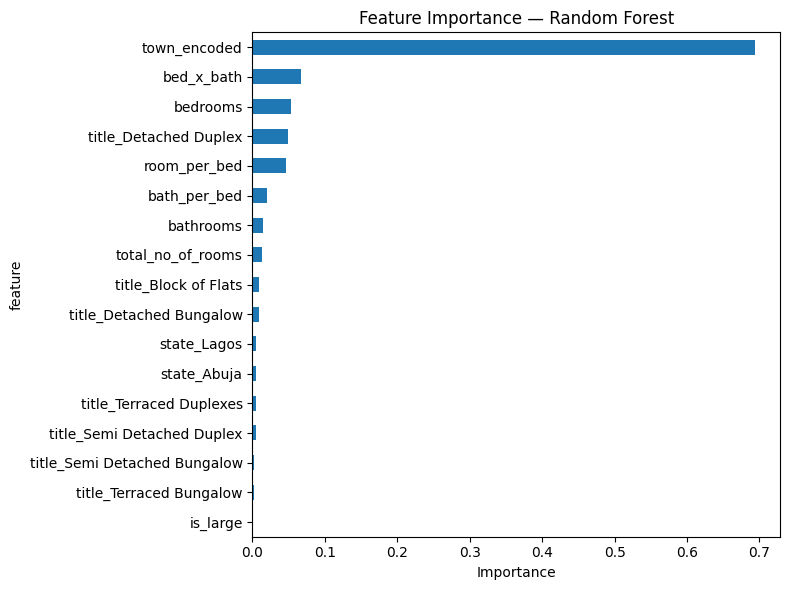

In [17]:
# Get feature names
ohe_features = list(
    model_rf.named_steps['columntransformer']
    .named_transformers_['ohe']
    .get_feature_names_out(['title', 'state'])
)

feature_names = ['town_encoded'] + ohe_features + numerical_cols

# Get importances
importances = model_rf.named_steps['randomforestregressor'].feature_importances_

feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=True)

feat_df.plot(kind='barh', x='feature', y='importance', figsize=(8, 6), legend=False)
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [18]:
coefficients = model_lr.named_steps['linearregression'].coef_
intercept = model_lr.named_steps['linearregression'].intercept_
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', ascending=False)

print(f"Intercept: {intercept:.4f}")
print(coef_df)

Intercept: 18.3337
                         feature  coefficient
0                   town_encoded     0.606283
11                     bathrooms     0.574359
12             total_no_of_rooms     0.493976
10                      bedrooms     0.329583
3          title_Detached Duplex     0.134904
16                      is_large     0.042247
8                    state_Abuja     0.008617
1           title_Block of Flats     0.001518
5     title_Semi Detached Duplex    -0.002789
9                    state_Lagos    -0.008617
6        title_Terraced Bungalow    -0.039795
4   title_Semi Detached Bungalow    -0.055523
7        title_Terraced Duplexes    -0.063725
2        title_Detached Bungalow    -0.100227
13                  bath_per_bed    -0.398141
14                  room_per_bed    -0.535360
15                    bed_x_bath    -0.624668


In [20]:
import joblib
joblib.dump(model_rf, '../model_rf.pkl')

['../model_rf.pkl']